In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def quality_checks(df):
    """ 
    Forced photometry quality filtering
    Section 6.1 Quality filtering https://arxiv.org/abs/2305.16279
    """
    mask = (
            (df['infobitssci'] < 33554432) & # bad photometric calibration
            (df['scisigpix'] <= 25) & # spatial noise-sigma per pixe
            (df['sciinpseeing'] <= 4.0) & # threshold for seeing
            df['forcediffimflux'].notna()
    )
    return df[mask].copy(), mask


def baseline_correction_and_uncertainty_scaling(df, baseline_jd_range=None):
    """
    Baseline correction (section 6.2 https://arxiv.org/abs/2305.16279)
    Uncertainty scaling with chi-square (section 4.1 https://arxiv.org/abs/2203.01461)
    """
    processed = []
    for name, group in df.groupby(['field', 'ccdid', 'qid', 'filter']):
        group = group.copy()
        baseline_dn = 0.0
        chi2_scale = 1.0

        if baseline_jd_range:
            start_mjd, end_mjd = baseline_jd_range
            quiet_lc = (group['jd'] >= start_mjd) & (group['jd'] <= end_mjd)
            if quiet_lc.any():
                if quiet_lc.sum() < 30:
                    # ZTF recommends more than 30 epochs
                    print(f"Warning: Current group {name} has <30 epochs")
                # median baseline 
                baseline_dn = group.loc[quiet_lc, 'forcediffimflux'].median()
                # uncertainty scaling
                chi2_scale = np.sqrt(group.loc[quiet_lc, 'forcediffimchisq'].mean())
                group['flux_uncertainty_correction'] = group['forcediffimfluxunc'] * chi2_scale

            else:
                group['flux_uncertainty_correction'] = group['forcediffimfluxunc']
        else:
            group['flux_uncertainty_correction'] = group['forcediffimfluxunc']

        # apply correction
        group['flux_baseline_correction'] = group['forcediffimflux'] - baseline_dn
        processed.append(group)

    return pd.concat(processed) if processed else pd.DataFrame()


In [49]:
df_raw = pd.read_csv("forced_photometry.csv")
df_filtered, quality_mask = quality_checks(df_raw)
baseline_range_mjd = (2459670, 2459743)
df_final = baseline_correction_and_uncertainty_scaling(df_filtered, baseline_jd_range=baseline_range_mjd)


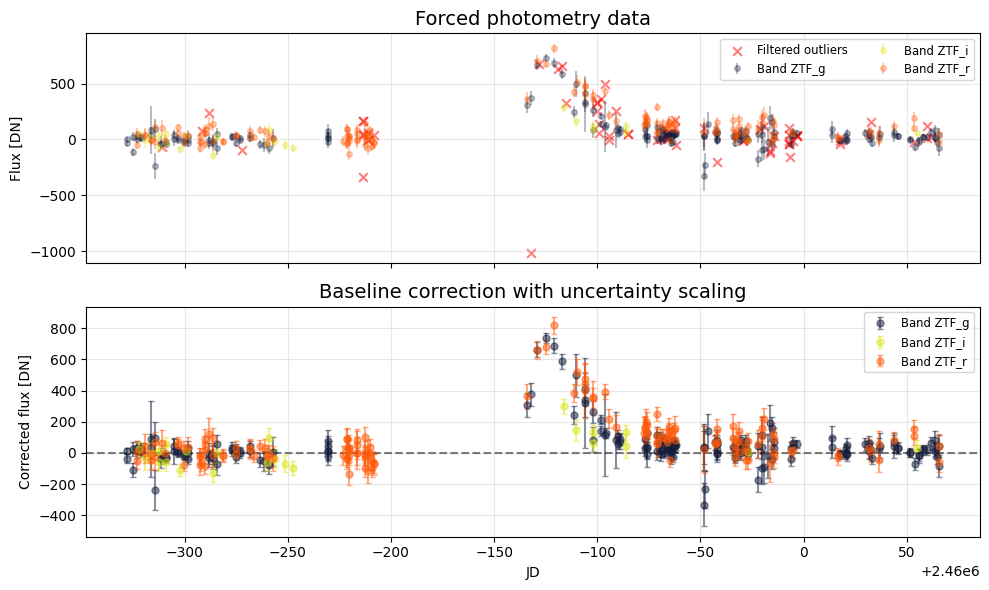

In [50]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

band_colors = {'ZTF_g': "#141E3C", 'ZTF_r': "#FF5B0B", 'ZTF_i': "#dce618"}
filters = sorted(df_raw['filter'].unique())

for band in filters:
    color = band_colors.get(band, 'black') 
    raw_b = df_raw[df_raw['filter'] == band]
    mask_b = quality_mask[df_raw['filter'] == band]
    final_b = df_final[df_final['filter'] == band]

    ax1.errorbar(raw_b[mask_b]['jd'], raw_b[mask_b]['forcediffimflux'],
                 yerr=raw_b[mask_b]['forcediffimfluxunc'],
                 fmt='o', color=color, alpha=0.3, markersize=4, label=f'Band {band}')

    outliers = raw_b[~mask_b]
    if not outliers.empty:
        ax1.scatter(outliers['jd'], outliers['forcediffimflux'],
                    marker='x', color='red', s=40, alpha=0.5,
                    label='Filtered outliers' if band == filters[0] else "")

    ax2.errorbar(final_b['jd'], final_b['flux_baseline_correction'],
                 yerr=final_b['flux_uncertainty_correction'],
                 fmt='o', color=color, markersize=5, capsize=2,
                 alpha=0.5,
                 label=f'Band {band}')

ax1.set_title("Forced photometry data", fontsize=14)
ax1.set_ylabel("Flux [DN]")
ax1.legend(loc='best', ncol=2, fontsize='small')
ax1.grid(True, alpha=0.3)

ax2.set_title("Baseline correction with uncertainty scaling", fontsize=14)
ax2.set_ylabel("Corrected flux [DN]")
ax2.set_xlabel("JD")
ax2.axhline(0, color='black', linestyle='--', alpha=0.5) 
ax2.legend(loc='best', ncol=1, fontsize='small')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
